In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
# GPU Memory Growth Setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from config import SimulationConfig
from scene_builder import build_scene
from channel_engine import compute_paths, apply_aging_and_get_ofdm_channel
from precoder import zf_precoder
from evaluator import calculate_nmse, calculate_achievable_rate


2026-07-27 04:35:04.164082: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
jitc_llvm_init(): LLVM API initialization failed ..


## Mobility & CSI Aging Analysis
This simulation evaluates the effect of mobility (velocity) and feedback delay ($\Delta t$) on CSI aging and achievable rate.
- **Base Station**: 64 antennas (UPA)
- **User Equipment**: 1 antenna
- **Frequency**: 3.5 GHz (TDD)


In [2]:
config = SimulationConfig()
scene, bs, ue = build_scene(config, config.fc_tdd)
paths = compute_paths(scene, max_depth=3)
print("Computed paths successfully")
scene.preview(paths=paths)


Computed paths successfully


In [3]:
# Render scene to image (for static output)
try:
    cm = scene.render(camera="preview", paths=paths, show_devices=True, show_paths=True, num_samples=128)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm)
    plt.axis('off')
    plt.title('Scene and Paths Render')
    plt.show()
except Exception as e:
    print("Renderer failed:", e)


Renderer failed: Scene.render() got an unexpected keyword argument 'show_paths'


In [4]:
# Parameter Sweep
results_nmse = {v: [] for v in config.velocities}
results_rate = {v: [] for v in config.velocities}

for v_kmh in config.velocities:
    v_ms = v_kmh / 3.6
    ue.velocity = [v_ms, 0.0, 0.0]
    
    # Recompute paths with new velocity to update doppler shifts
    paths_v = compute_paths(scene, max_depth=3)
    
    for dt in config.delta_t_list:
        # Channel at t=0
        h_est = apply_aging_and_get_ofdm_channel(paths_v, config, config.fc_tdd, 0.0)
        h_est = tf.reshape(h_est, [config.num_ue_ant_rows * config.num_ue_ant_cols,
                                   config.num_bs_ant_rows * config.num_bs_ant_cols,
                                   config.num_active_subcarriers])
        
        # Channel at t=dt
        h_true = apply_aging_and_get_ofdm_channel(paths_v, config, config.fc_tdd, dt)
        h_true = tf.reshape(h_true, [config.num_ue_ant_rows * config.num_ue_ant_cols,
                                     config.num_bs_ant_rows * config.num_bs_ant_cols,
                                     config.num_active_subcarriers])
             
        # Calculate NMSE
        nmse = calculate_nmse(h_true, h_est)
        results_nmse[v_kmh].append(nmse)
        
        # Precoder based on h_est
        w_zf = zf_precoder(h_est)
        
        # Rate using h_true and w_zf
        rate = calculate_achievable_rate(h_true, w_zf, snr_db=20.0)
        results_rate[v_kmh].append(rate)
        
print("Sweep completed.")


I0000 00:00:1785126908.884436  244266 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 37173 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:81:00.0, compute capability: 8.9
I0000 00:00:1785126908.896126  244266 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 21290 MB memory:  -> device: 1, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c1:00.0, compute capability: 8.9
I0000 00:00:1785126908.899507  244266 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 29865 MB memory:  -> device: 2, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c2:00.0, compute capability: 8.9
I0000 00:00:1785126909.456786  244266 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x361cdb20


Sweep completed.


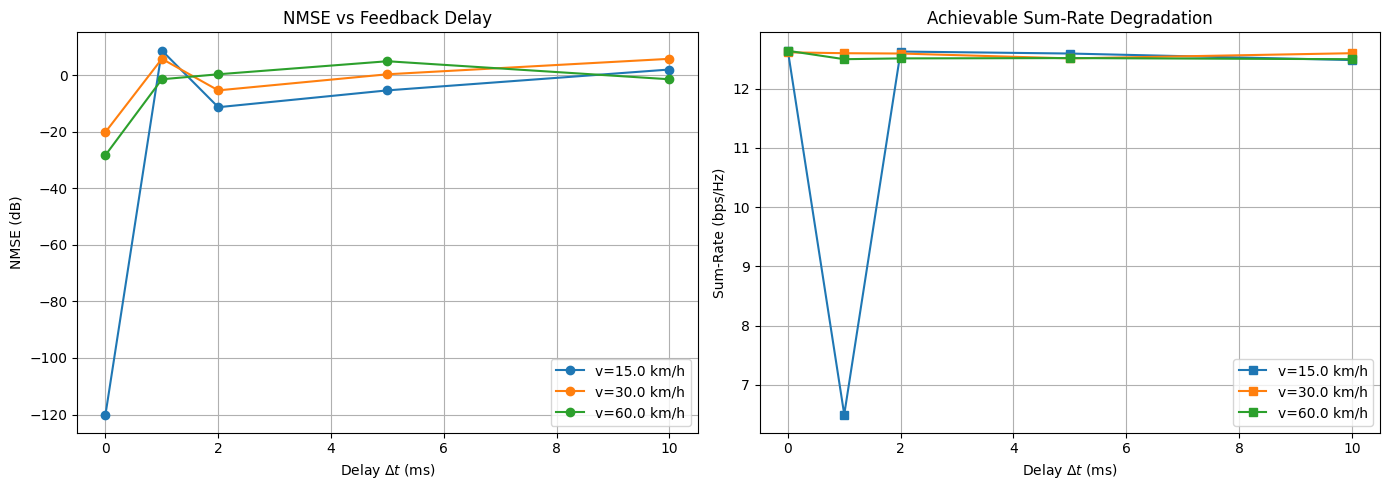

In [5]:
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for v_kmh in config.velocities:
    nmse_db = 10.0 * np.log10(np.array(results_nmse[v_kmh]) + 1e-12)
    axes[0].plot(np.array(config.delta_t_list)*1000, nmse_db, marker='o', label=f'v={v_kmh} km/h')
axes[0].set_title('NMSE vs Feedback Delay')
axes[0].set_xlabel('Delay $\Delta t$ (ms)')
axes[0].set_ylabel('NMSE (dB)')
axes[0].grid(True)
axes[0].legend()

for v_kmh in config.velocities:
    axes[1].plot(np.array(config.delta_t_list)*1000, results_rate[v_kmh], marker='s', label=f'v={v_kmh} km/h')
axes[1].set_title('Achievable Sum-Rate Degradation')
axes[1].set_xlabel('Delay $\Delta t$ (ms)')
axes[1].set_ylabel('Sum-Rate (bps/Hz)')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


## Visualization
Let's visualize the scene, paths, and the channel magnitude.

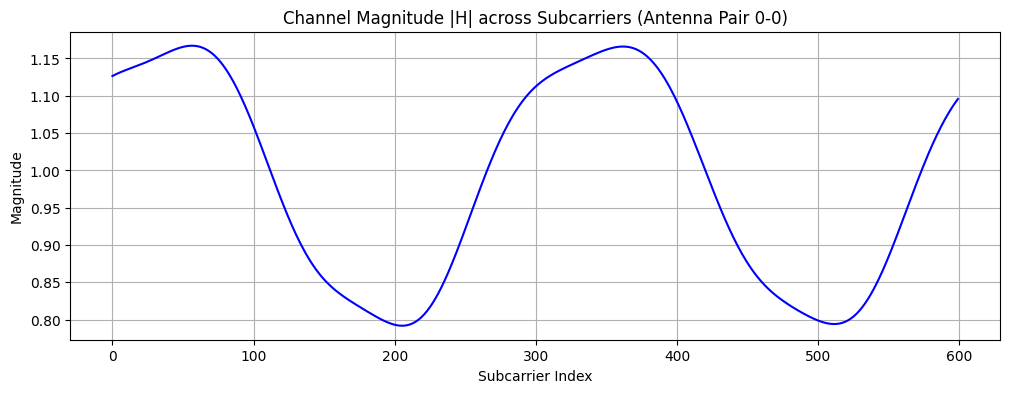

In [6]:
# Channel Magnitude Visualization
plt.figure(figsize=(12, 4))
# h_est is the channel at t=0 for the last velocity evaluated
h_mag = np.abs(h_est[0, 0, :])
plt.plot(h_mag, color='b')
plt.title("Channel Magnitude |H| across Subcarriers (Antenna Pair 0-0)")
plt.xlabel("Subcarrier Index")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()
